In [102]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))  # repo root, so src/ and analysis/ import

from src.data import build_all
from src.distances import compute_euclidean_distances, compute_mahalanobis_distances
from analysis.arsenal import compare_all_arsenals, arsenal_internal_distances, real_arsenal_silhouette_scores, PITCH_CHAR_FEATURES
from analysis.biomech import evaluate_biomech_features, biomech_threshold_coverage, biomech_threshold_calibration, plot_threshold_calibration
from analysis.stability import stability_analysis


import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Ellipse
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import warnings

warnings.filterwarnings("ignore")

Filter data for pre-2026 to make clean, unbiased observations and decisions on the data

In [104]:
data = build_all(live=False)

statcast_clean  = data['statcast_clean']
statcast_clean  = statcast_clean[statcast_clean['game_year'] < 2026]
pitch_type_summ = data['pitch_type_summ']
pitch_type_summ = pitch_type_summ[pitch_type_summ['game_year'] < 2026]
pitcher_summ    = data['pitcher_summ']
pitcher_summ    = pitcher_summ[pitcher_summ['game_year'] < 2026]
pitcher_summ_r  = data['pitcher_summ_r']
pitcher_summ_r  = pitcher_summ_r[pitcher_summ_r['game_year'] < 2026]
pitcher_summ_l  = data['pitcher_summ_l']
pitcher_summ_l  = pitcher_summ_l[pitcher_summ_l['game_year'] < 2026]
pitch_type_r  = data['pitch_type_r']
pitch_type_r  = pitch_type_r[pitch_type_r['game_year'] < 2026]
pitch_type_l  = data['pitch_type_l']
pitch_type_l  = pitch_type_l[pitch_type_l['game_year'] < 2026]

statcast_clean_25 = statcast_clean[statcast_clean['game_year'] == 2025]

In [105]:
pitch_type_summ.head()

,pitch_type,pitcher,player_name,p_throws,game_year,release_speed,release_pos_x,release_pos_z,pfx_x,pfx_z,release_spin_rate,release_extension,release_pos_y,spin_axis,arm_angle,n
0,CH,425794,"Wainwright, Adam",R,2021,82.729744,-1.333487,6.222359,-1.152821,0.643179,1714.097938,6.495897,54.000974,222.546392,43.993229,195
1,CH,425794,"Wainwright, Adam",R,2022,82.182540,-1.314709,6.223757,-1.192593,0.668889,1763.634921,6.424339,54.075979,225.285714,42.871429,189
2,CH,425794,"Wainwright, Adam",R,2023,81.431461,-1.335618,6.142360,-1.168652,0.729663,1655.179775,6.511236,53.991685,225.898876,42.803529,89
3,CH,425844,"Greinke, Zack",R,2021,86.350791,-1.371002,6.311160,-1.065747,0.371793,1593.499115,5.907381,54.591810,225.651327,43.748592,569
4,CH,425844,"Greinke, Zack",R,2022,86.468984,-1.825642,6.142861,-1.067433,0.317032,1643.493298,5.916845,54.583316,229.329759,39.724722,374


# Pitch Characteristics

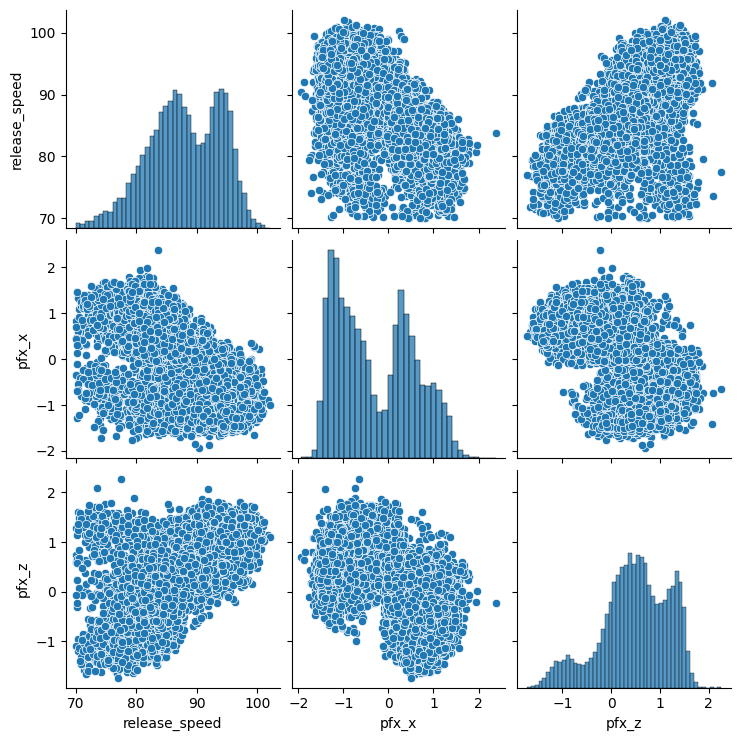

In [106]:
sns.pairplot(
    pitch_type_r,
    vars=["release_speed", "pfx_x", "pfx_z"],
    #hue="pitch_type"
);

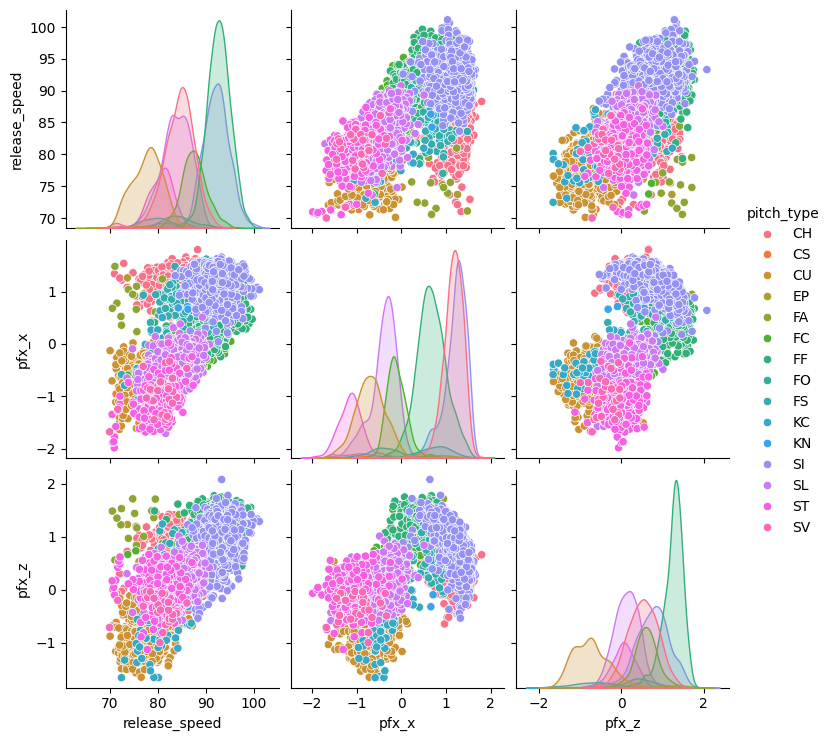

In [107]:
sns.pairplot(
    pitch_type_l,
    vars=["release_speed", "pfx_x", "pfx_z"],
    hue="pitch_type"
);

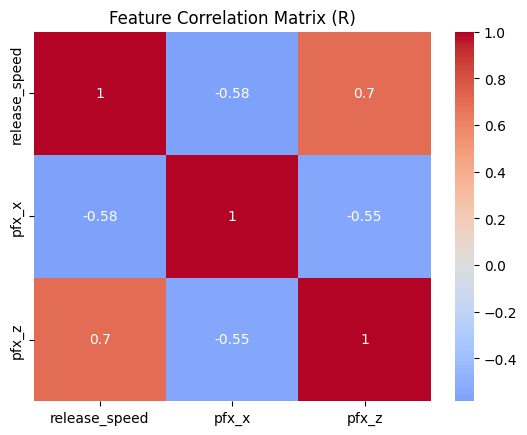

In [108]:
corr_r = pitch_type_r[["release_speed", "pfx_x", "pfx_z"]].corr()

sns.heatmap(corr_r, annot=True, cmap="coolwarm", center=0)
plt.title("Feature Correlation Matrix (R)");

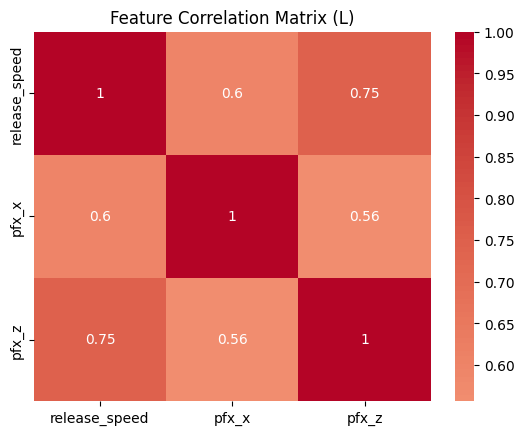

In [109]:
corr_l = pitch_type_l[["release_speed", "pfx_x", "pfx_z"]].corr()

sns.heatmap(corr_l, annot=True, cmap="coolwarm", center=0)
plt.title("Feature Correlation Matrix (L)");

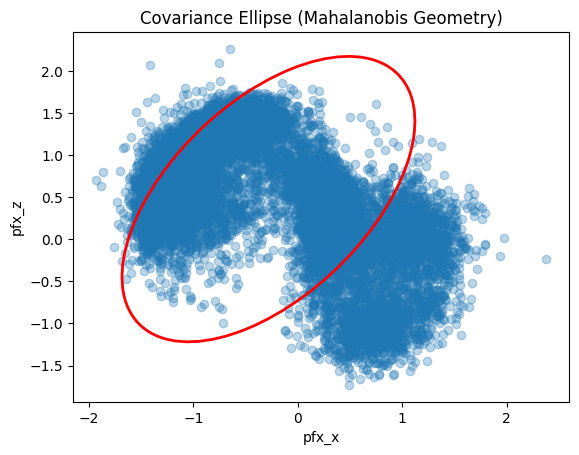

In [110]:
X = pitch_type_r[["pfx_x", "pfx_z"]].dropna().values
cov = np.cov(X, rowvar=False)
mean = X.mean(axis=0)

eigvals, eigvecs = np.linalg.eigh(cov)

angle = np.degrees(np.arctan2(*eigvecs[:,1][::-1]))

fig, ax = plt.subplots()
ax.scatter(X[:,0], X[:,1], alpha=0.3)

ellipse = Ellipse(
    xy=mean,
    width=2*np.sqrt(eigvals[0])*2,
    height=2*np.sqrt(eigvals[1])*2,
    angle=angle,
    edgecolor='red',
    fc='None',
    lw=2
)

ax.add_patch(ellipse)
ax.set_xlabel("pfx_x")
ax.set_ylabel("pfx_z")
plt.title("Covariance Ellipse (Mahalanobis Geometry)")
plt.show()

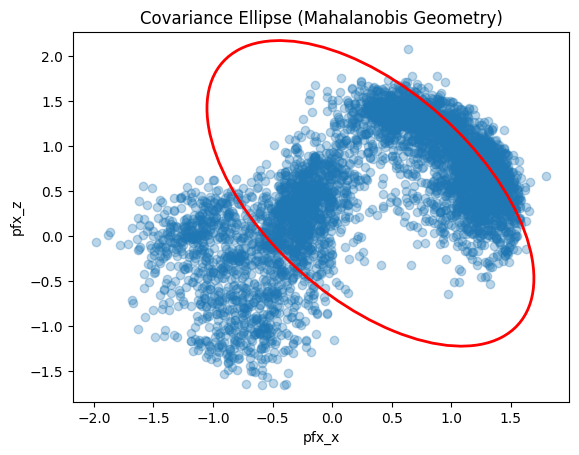

In [111]:
X = pitch_type_l[["pfx_x", "pfx_z"]].dropna().values
cov = np.cov(X, rowvar=False)
mean = X.mean(axis=0)

eigvals, eigvecs = np.linalg.eigh(cov)

angle = np.degrees(np.arctan2(*eigvecs[:,1][::-1]))

fig, ax = plt.subplots()
ax.scatter(X[:,0], X[:,1], alpha=0.3)

ellipse = Ellipse(
    xy=mean,
    width=2*np.sqrt(eigvals[0])*2,
    height=2*np.sqrt(eigvals[1])*2,
    angle=angle,
    edgecolor='red',
    fc='None',
    lw=2
)

ax.add_patch(ellipse)
ax.set_xlabel("pfx_x")
ax.set_ylabel("pfx_z")
plt.title("Covariance Ellipse (Mahalanobis Geometry)")
plt.show()

In [112]:
X = pitch_type_r[["release_speed", "pfx_x", "pfx_z"]].dropna().values
VI = np.linalg.pinv(np.cov(X, rowvar=False))

def mahalanobis_components(x, y, VI):
    diff = x - y
    return diff * (VI @ diff)

# Example: inspect a weird pair
i, j = 0, 1  # replace with a suspicious pair
comp = mahalanobis_components(X[i], X[j], VI)

pd.Series(comp, index=["release_speed", "pfx_x", "pfx_z"])

release_speed    0.025332
pfx_x            0.005506
pfx_z            0.006076
dtype: float64

In [113]:
X = pitch_type_l[["release_speed", "pfx_x", "pfx_z"]].dropna().values
VI = np.linalg.pinv(np.cov(X, rowvar=False))

def mahalanobis_components(x, y, VI):
    diff = x - y
    return diff * (VI @ diff)

# Example: inspect a weird pair
i, j = 0, 1  # replace with a suspicious pair
comp = mahalanobis_components(X[i], X[j], VI)

pd.Series(comp, index=["release_speed", "pfx_x", "pfx_z"])

release_speed    1.713522
pfx_x            0.008843
pfx_z           -0.034073
dtype: float64

# Biomechanics Characteristics

In [114]:
pitcher_summ_r.head()

,pitcher,p_throws,player_name,game_year,release_pos_x,release_pos_z,release_extension,arm_angle,n,max_velo,max_spin,pri_fb,fb_pfx_x,fb_n,pri_fb_cd,active_spin_fastball,FB_type
0,425794,R,"Wainwright, Adam",2021,-1.195318,6.292470,6.478433,46.499203,3037,89.050985,2840.411298,SI,-1.061773,863.0,0,76.4,FF
1,425794,R,"Wainwright, Adam",2022,-1.119490,6.303870,6.419000,46.148490,3080,88.566476,2777.854856,SI,-1.085446,874.0,0,75.8,FF
2,425794,R,"Wainwright, Adam",2023,-1.246479,6.218935,6.475293,45.361083,1690,86.875000,2663.096110,SI,-1.104411,560.0,0,76.9,FF
3,425844,R,"Greinke, Zack",2021,-1.271575,6.362570,5.938383,47.284900,2463,89.495973,2406.351852,FF,-0.107953,1026.0,1,78.7,FF
4,425844,R,"Greinke, Zack",2022,-1.725025,6.204550,5.905016,42.991710,2213,89.450000,2447.595238,FF,-0.173206,867.0,1,79.2,FF


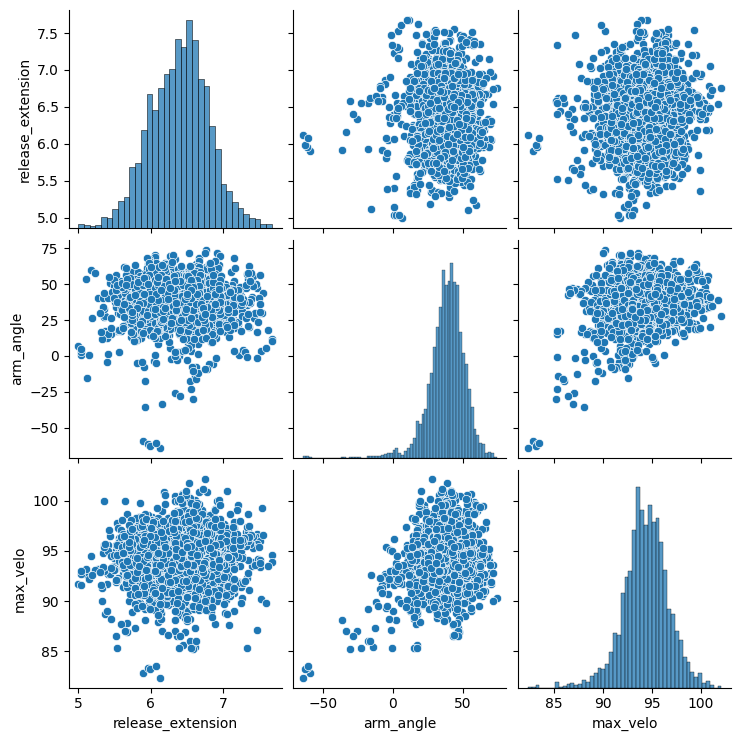

In [115]:
sns.pairplot(
    pitcher_summ_r[pitcher_summ_r['n']>100],
    vars=['release_extension', 'arm_angle', 'max_velo'],
);

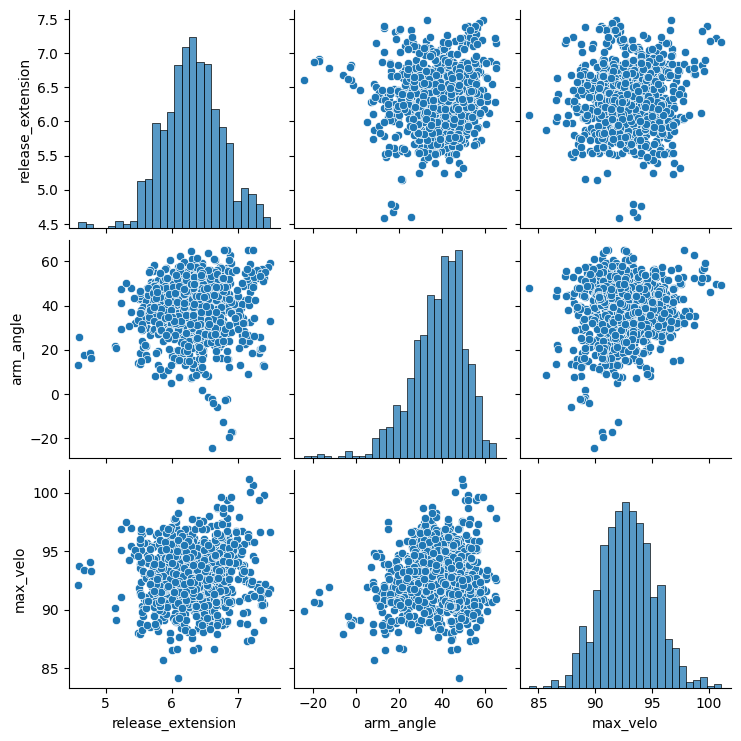

In [116]:
sns.pairplot(
    pitcher_summ_l[pitcher_summ_l['n']>100],
    vars=['release_extension', 'arm_angle', 'max_velo'],
);

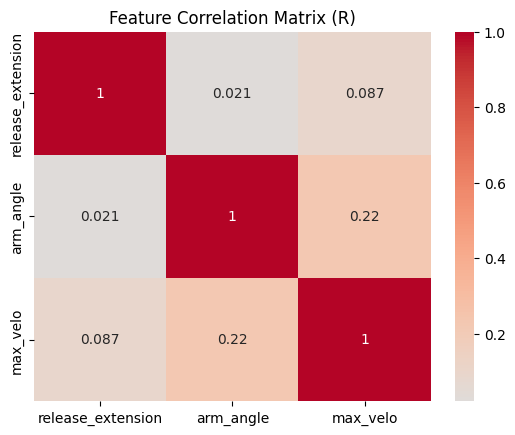

In [117]:
corr = pitcher_summ_r[['release_extension', 'arm_angle', 'max_velo']].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.title("Feature Correlation Matrix (R)");

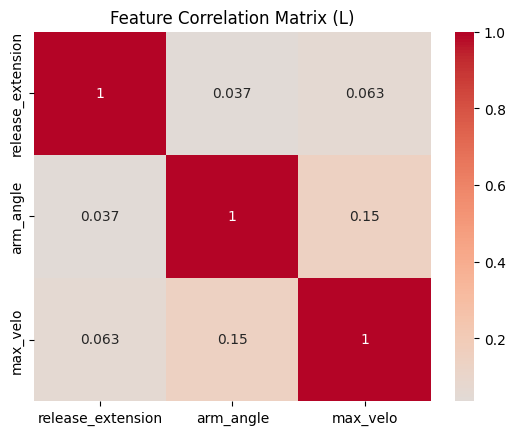

In [118]:
corr = pitcher_summ_l[['release_extension', 'arm_angle', 'max_velo']].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.title("Feature Correlation Matrix (L)");

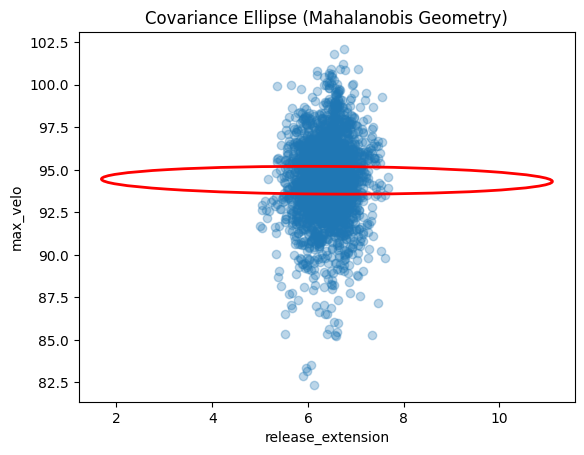

In [119]:
X = pitcher_summ_r[["release_extension", "max_velo"]].dropna().values
cov = np.cov(X, rowvar=False)
mean = X.mean(axis=0)

eigvals, eigvecs = np.linalg.eigh(cov)

angle = np.degrees(np.arctan2(*eigvecs[:,1][::-1]))

fig, ax = plt.subplots()
ax.scatter(X[:,0], X[:,1], alpha=0.3)

ellipse = Ellipse(
    xy=mean,
    width=2*np.sqrt(eigvals[0])*2,
    height=2*np.sqrt(eigvals[1])*2,
    angle=angle,
    edgecolor='red',
    fc='None',
    lw=2
)

ax.add_patch(ellipse)
ax.set_xlabel("release_extension")
ax.set_ylabel("max_velo")
plt.title("Covariance Ellipse (Mahalanobis Geometry)");

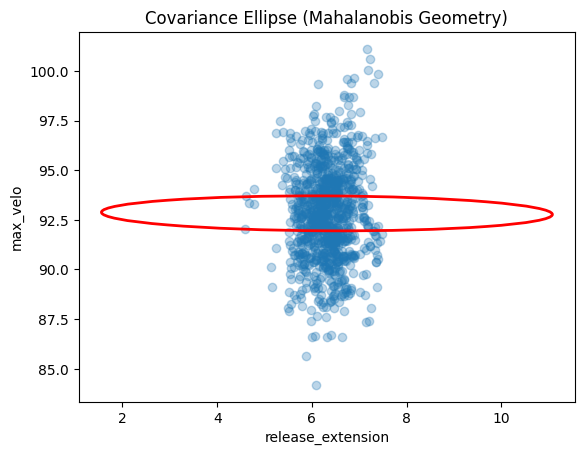

In [120]:
X = pitcher_summ_l[["release_extension", "max_velo"]].dropna().values
cov = np.cov(X, rowvar=False)
mean = X.mean(axis=0)

eigvals, eigvecs = np.linalg.eigh(cov)

angle = np.degrees(np.arctan2(*eigvecs[:,1][::-1]))

fig, ax = plt.subplots()
ax.scatter(X[:,0], X[:,1], alpha=0.3)

ellipse = Ellipse(
    xy=mean,
    width=2*np.sqrt(eigvals[0])*2,
    height=2*np.sqrt(eigvals[1])*2,
    angle=angle,
    edgecolor='red',
    fc='None',
    lw=2
)

ax.add_patch(ellipse)
ax.set_xlabel("release_extension")
ax.set_ylabel("max_velo")
plt.title("Covariance Ellipse (Mahalanobis Geometry)");

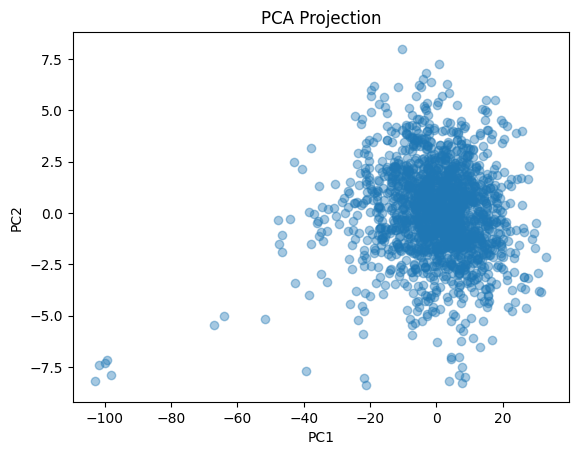

In [121]:
X = pitcher_summ_r[pitcher_summ_r['n']>500][['release_extension', 'arm_angle', 'max_velo']].dropna().values

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.scatter(X_pca[:,0], X_pca[:,1], alpha=0.4)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Projection");

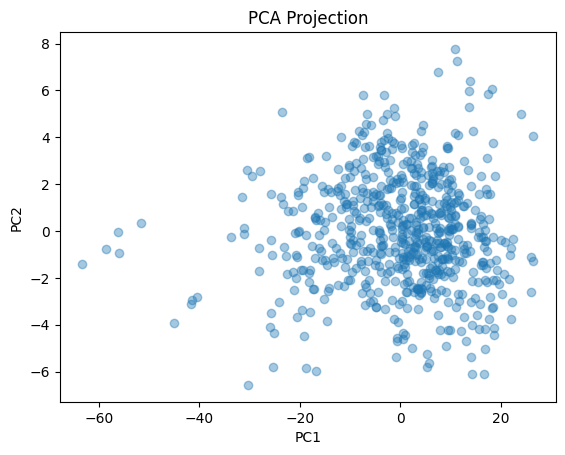

In [122]:
X = pitcher_summ_l[pitcher_summ_l['n']>500][['release_extension', 'arm_angle', 'max_velo']].dropna().values

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.scatter(X_pca[:,0], X_pca[:,1], alpha=0.4)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Projection");

# Hyperparameter Optimization

## Data Prep

In [123]:
pitch_type_distance_r = compute_euclidean_distances(pitch_type_r, 
                                                    features=["release_speed", "pfx_x", "pfx_z"], 
                                                    label_cols=["player_name", "pitch_type", "game_year"], 
                                                    min_pitches = 20)
pitch_type_distance_l = compute_euclidean_distances(pitch_type_l, 
                                                    features=["release_speed", "pfx_x", "pfx_z"], 
                                                    label_cols=["player_name", "pitch_type", "game_year"], 
                                                    min_pitches = 20)

Filter to 2025 data only for practical purposes

In [124]:
pitch_type_distance_r_25 = pitch_type_distance_r[(pitch_type_distance_r['game_year1']==2025) & 
    (pitch_type_distance_r['game_year2']==2025)]
pitch_type_distance_l_25 = pitch_type_distance_l[(pitch_type_distance_l['game_year1']==2025) & 
    (pitch_type_distance_l['game_year2']==2025)]

In [125]:
arsenal_comp_l_25 = compare_all_arsenals(pitch_type_distance_l_25, 50)
arsenal_comp_r_25 = compare_all_arsenals(pitch_type_distance_r_25, 50)

2.013743173850861
2.0162059293092662


In [126]:
arsenal_comp_l_25

,player_name1,game_year1,player_name2,game_year2,arsenal_distance
0,"Akin, Keegan",2025,"Bowden, Ben",2025,0.247570
1,"Burke, Brock",2025,"Peralta, Wandy",2025,0.249016
2,"Perdomo, Angel",2025,"Walker, Josh",2025,0.309144
3,"Perdomo, Angel",2025,"Poche, Colin",2025,0.330971
4,"Harrison, Kyle",2025,"Shuster, Jared",2025,0.341067
...,...,...,...,...,...
20095,"Cosgrove, Tom",2025,"Montgomery, Mason",2025,2.641804
20096,"Morán, Jovani",2025,"Rogers, Taylor",2025,2.643458
20097,"Bruihl, Justin",2025,"Cruz, Omar",2025,2.654677
20098,"Bruihl, Justin",2025,"Montgomery, Mason",2025,2.678277


## Define Biomechanics

In [127]:
feature_sets = {
    'Extension + Arm Angle + Max Velocity + Max Spin':
       ['release_extension', 'arm_angle', 'max_velo', 'max_spin'],

    'Extension + Arm Angle + Max Velocity':
       ['release_extension', 'arm_angle', 'max_velo'],

    'Extension + Arm Angle + Max Velocity + Primary Fastball Indicator':
        ['release_extension', 'arm_angle', 'max_velo', 'pri_fb_cd'],

    'Extension + Arm Angle + Active Spin (Fastball)':
        ['release_extension', 'arm_angle', 'active_spin_fastball'],

    'Extension + Arm Angle + Max Velocity + Active Spin (Fastball)':
        ['release_extension', 'arm_angle', 'max_velo', 'active_spin_fastball'],

    'Extension + Arm Angle + Max Velocity + Active Spin (Fastball) + Release Position X':
        ['release_extension', 'arm_angle', 'max_velo', 'active_spin_fastball', 'release_pos_x'],

    'Extension + Arm Angle + Max Velocity + Active Spin (Fastball) + Release Position Z':
        ['release_extension', 'arm_angle', 'max_velo', 'active_spin_fastball', 'release_pos_z'],

    'Extension + Arm Angle + Max Velocity + Active Spin (Fastball) + Release Position X + Release Position Z':
        ['release_extension', 'arm_angle', 'max_velo', 'active_spin_fastball', 'release_pos_x', 'release_pos_z'],
}

In [128]:
pitcher_summ_r_25 = pitcher_summ_r[pitcher_summ_r['game_year']==2025]
pitcher_summ_l_25 = pitcher_summ_l[pitcher_summ_l['game_year']==2025]

In [129]:
results_r_euc = evaluate_biomech_features(pitcher_summ_r_25, 
                                          arsenal_comp_r_25, 
                                          feature_sets, 
                                          min_pitches=20,
                                          distance_fn=compute_euclidean_distances)
print("RHP:\n", results_r_euc.to_string(index=False))

results_l_euc = evaluate_biomech_features(pitcher_summ_l_25, 
                                          arsenal_comp_l_25, 
                                          feature_sets, 
                                          min_pitches=20,
                                          distance_fn=compute_euclidean_distances)
print("\nLHP:\n", results_l_euc.to_string(index=False))

RHP:
                                                                                                Features  Spearman_rho  p_value
                                                         Extension + Arm Angle + Active Spin (Fastball)        0.2683      0.0
                                      Extension + Arm Angle + Max Velocity + Primary Fastball Indicator        0.3578      0.0
                                                        Extension + Arm Angle + Max Velocity + Max Spin        0.3679      0.0
                                                                   Extension + Arm Angle + Max Velocity        0.3786      0.0
Extension + Arm Angle + Max Velocity + Active Spin (Fastball) + Release Position X + Release Position Z        0.3939      0.0
                     Extension + Arm Angle + Max Velocity + Active Spin (Fastball) + Release Position X        0.3980      0.0
                     Extension + Arm Angle + Max Velocity + Active Spin (Fastball) + Release Position Z  

In [130]:
results_r_mah = evaluate_biomech_features(pitcher_summ_r_25, 
                                          arsenal_comp_r_25, 
                                          feature_sets, 
                                          min_pitches=20,
                                          distance_fn=compute_mahalanobis_distances)
print("RHP:\n", results_r_mah.to_string(index=False))

results_l_mah = evaluate_biomech_features(pitcher_summ_l_25, 
                                          arsenal_comp_l_25, 
                                          feature_sets, 
                                          min_pitches=20,
                                          distance_fn=compute_mahalanobis_distances)
print("\nLHP:\n", results_l_mah.to_string(index=False))

RHP:
                                                                                                Features  Spearman_rho  p_value
                                                         Extension + Arm Angle + Active Spin (Fastball)        0.2655      0.0
                                      Extension + Arm Angle + Max Velocity + Primary Fastball Indicator        0.3406      0.0
Extension + Arm Angle + Max Velocity + Active Spin (Fastball) + Release Position X + Release Position Z        0.3476      0.0
                     Extension + Arm Angle + Max Velocity + Active Spin (Fastball) + Release Position Z        0.3628      0.0
                                                        Extension + Arm Angle + Max Velocity + Max Spin        0.3667      0.0
                                                                   Extension + Arm Angle + Max Velocity        0.3731      0.0
                     Extension + Arm Angle + Max Velocity + Active Spin (Fastball) + Release Position X  

**No matter how you slice it, extension, arm angle, max velocity, and active spin on the fastball are the best features to define biomechanics**

Note: Spearman's rho is used to facilitate comparison across different feature sets

## Minimum Pitches Tuning

In [131]:
stability_df_biomech, raw_biomech = stability_analysis(statcast_clean_25, 
                                                    ['release_extension', 'arm_angle'],
                                                    sample_sizes = ([5,10,15,20,25,30]),
                                                    n_replicates=100,
                                                    n_pitchers=100
                                                    )

In [132]:
population_sds_biomech = {
    'arm_angle':         pitcher_summ['arm_angle'].std(),
    'release_extension': pitcher_summ['release_extension'].std(),
}

In [133]:
stability_df_pitch, raw_pitch = stability_analysis(
    statcast_clean_25,
    features=['release_speed', 'pfx_x', 'pfx_z'],
    group_by_pitch_type=True,
    sample_sizes = ([5,10,15,20,25,30]),
    n_replicates=100,
    n_pitchers=100
)

In [134]:
population_sds_pitch = {
    'release_speed': pitch_type_summ['release_speed'].std(),
    'pfx_x':         pitch_type_summ['pfx_x'].std(),
    'pfx_z':         pitch_type_summ['pfx_z'].std(),
}

In [135]:
stability_df_pitch_ff, raw_pitch_ff = stability_analysis(
    statcast_clean_25[statcast_clean_25['pitch_type']=='FF'],
    features=['release_speed'],
    group_by_pitch_type=True,
    sample_sizes = ([5,10,15,20,25,30]),
    n_replicates=100,
    n_pitchers=100
)

In [136]:
pitch_type_summ_ff = pitch_type_summ[pitch_type_summ['pitch_type']=='FF']
population_sds_pitch_ff = {
    'release_speed': pitch_type_summ_ff['release_speed'].std()
}

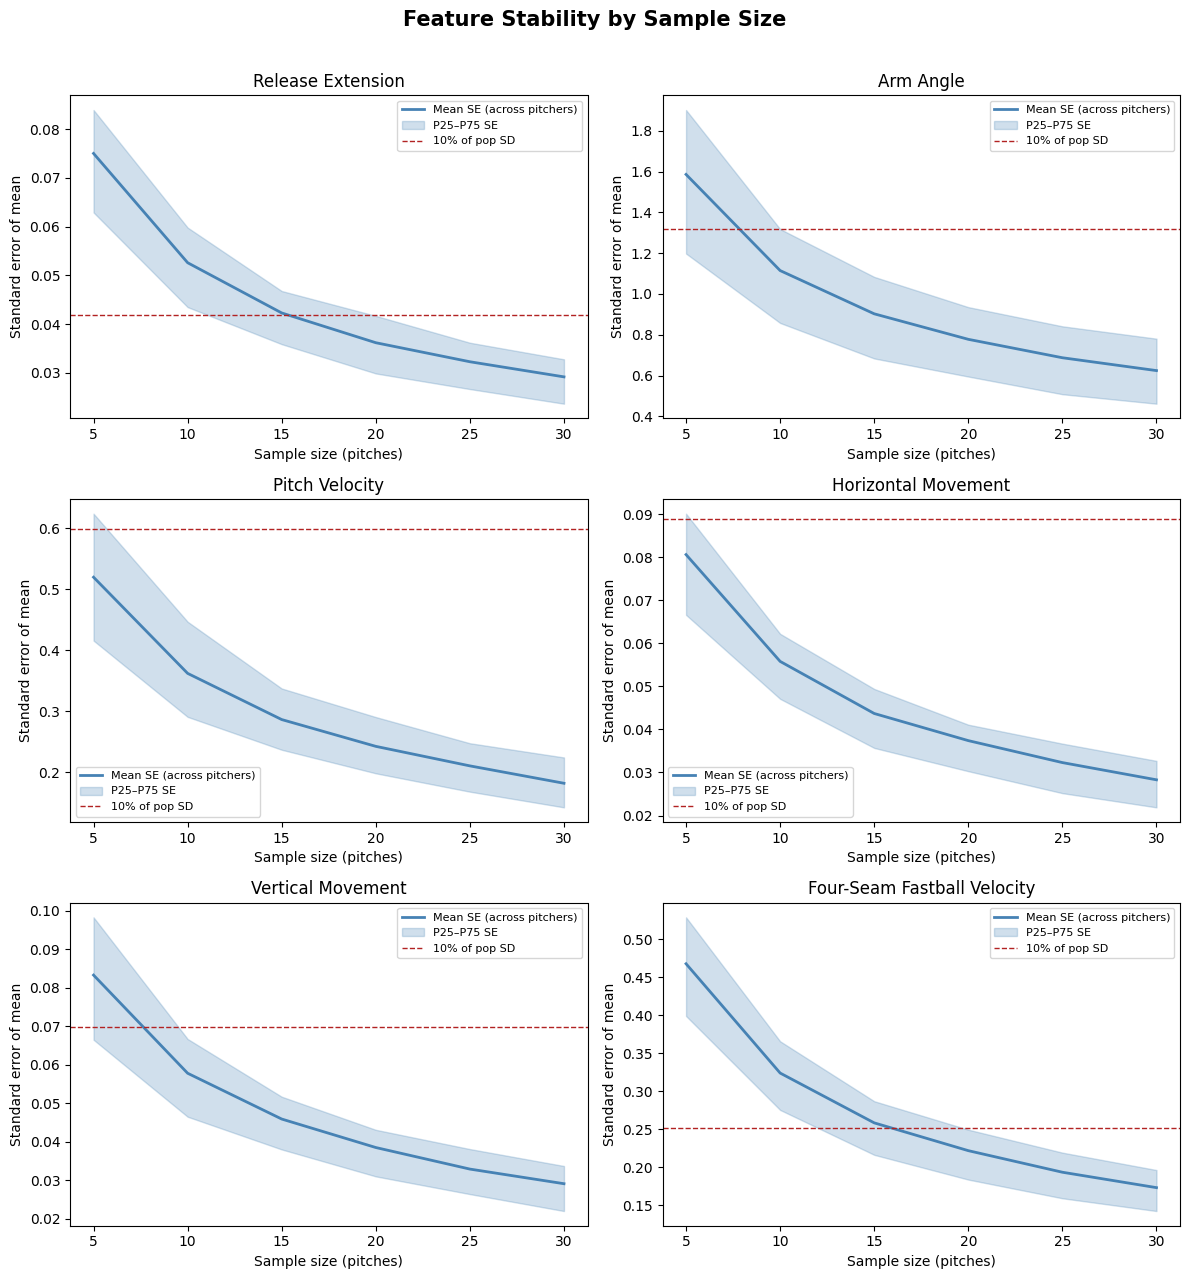

In [137]:
# All six feature stabilities on one figure (2 across, 3 down).
# Each panel: (stability_df, feature column, English title, population SD)
panels = [
    (stability_df_biomech,  'release_extension', 'Release Extension',   population_sds_biomech['release_extension']),
    (stability_df_biomech,  'arm_angle',         'Arm Angle',           population_sds_biomech['arm_angle']),
    (stability_df_pitch,    'release_speed',     'Pitch Velocity',      population_sds_pitch['release_speed']),
    (stability_df_pitch,    'pfx_x',             'Horizontal Movement', population_sds_pitch['pfx_x']),
    (stability_df_pitch,    'pfx_z',             'Vertical Movement',   population_sds_pitch['pfx_z']),
    (stability_df_pitch_ff, 'release_speed',     'Four-Seam Fastball Velocity',  population_sds_pitch_ff['release_speed']),
]

fig, axes = plt.subplots(3, 2, figsize=(12, 13))
axes = axes.flatten()

for ax, (df, feature, title, pop_sd) in zip(axes, panels):
    sub = df[df['feature'] == feature]

    ax.plot(sub['sample_size'], sub['mean_se'], color='steelblue', lw=2, label='Mean SE (across pitchers)')
    ax.fill_between(sub['sample_size'], sub['p25_se'], sub['p75_se'],
                    alpha=0.25, color='steelblue', label='P25–P75 SE')

    threshold = pop_sd * 0.1
    ax.axhline(threshold, color='firebrick', lw=1, linestyle='--', label=f'10% of pop SD')

    ax.set_title(title)
    ax.set_xlabel('Sample size (pitches)')
    ax.set_ylabel('Standard error of mean')
    ax.legend(fontsize=8)

fig.suptitle('Feature Stability by Sample Size', fontsize=15, fontweight='bold')

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

Stability measurement: Sampling SD of each feature mean across 100 bootstrap resamples of N pitches per pitcher; the dashed line marks 10% of the population SD.

Both pitch characteristics and biomechanical features stabilize very quickly. The slowest features to stabilize are extension and fastball velocity, and even they are stable after 20 pitches. We will use 20 pitches as the minimum number of pitches for analysis going forward.

## Arsenal Minimum Distance

In [138]:
global_scaler = StandardScaler().fit(pitch_type_summ[PITCH_CHAR_FEATURES].dropna().values)
arsenal_df = arsenal_internal_distances(pitch_type_summ, global_scaler=global_scaler)

── Arsenal internal distances (across all pitcher-years) ──
       mean_min_dist  min_min_dist  p25_min_dist  p50_min_dist  p75_min_dist  p90_min_dist
count       3753.000      3753.000      3753.000      3753.000      3753.000      3753.000
mean           1.723         1.437         1.444         1.592         1.870         2.085
std            0.659         0.784         0.778         0.696         0.628         0.631
min            0.319         0.044         0.044         0.080         0.319         0.319
25%            1.286         0.909         0.919         1.144         1.455         1.650
50%            1.556         1.201         1.202         1.407         1.752         1.982
75%            1.962         1.757         1.757         1.806         2.113         2.421
max            5.568         5.568         5.568         5.568         5.568         5.568


Min_min_dist shows the minimum distance between any two pitches in an arsenal. For example, if a sinker and fastball are the two most similar pitches in an arsenal, their distance apart will be what goes into the min_min_dist. 

In contrast, the mean_min_dist calculates the mean of every pitch's closest neighbor (FF closest pitch, SI closest pitch, CH closest pitch, etc.)

Since the purpose of this evaluation is to define the minimum threshold for uniqueness to add to an arsenal, I will use the median min_min_dist of about 1.2 as a conservative estimate, meaning that if there is a suggestion for a new pitch, it must be at least as far from every pitch in the current arsenal as the median closest distance.

## Biomechanical Maximum Distance

In [183]:
cov_r = biomech_threshold_coverage(pitcher_summ_r, 
                                   thresholds=(1.0, 1.25, 1.5, 1.75, 2.0),
                                   min_pitches=20)

── Biomech threshold coverage ──
 threshold  mean_comps  p10_comps  p25_comps  p50_comps  p75_comps  pct_zero  pct_lt5
      1.00        71.3          6         22         60        111       3.1      9.0
      1.25       135.6         14         48        124        209       2.1      5.2
      1.50       220.5         30         98        214        333       1.2      3.4
      1.75       318.4         59        165        326        469       0.6      2.3
      2.00       421.2        100        264        455        597       0.2      1.7


In [184]:
cov_l = biomech_threshold_coverage(pitcher_summ_l, 
                                   thresholds=(1.0, 1.25, 1.5, 1.75, 2.0),
                                   min_pitches=20)

── Biomech threshold coverage ──
 threshold  mean_comps  p10_comps  p25_comps  p50_comps  p75_comps  pct_zero  pct_lt5
      1.00        21.9          2          7         18         33       4.5     17.0
      1.25        42.3          5         16         37         62       2.3      8.5
      1.50        69.8         11         31         67        102       1.4      5.7
      1.75       101.4         21         54        102        145       0.6      3.1
      2.00       136.4         33         82        144        192       0.3      2.3


Find examples of pitchers 1.5 apart


In [185]:
biomech_dist_l = compute_euclidean_distances(
    pitcher_summ_l,
    features=['release_extension', 'arm_angle', 'max_velo', 'active_spin_fastball'],
    label_cols=['player_name', 'game_year'],
    min_pitches=20,
    include_features=True
)

In [186]:
biomech_dist_l[(biomech_dist_l['distance']>1.49995) & (biomech_dist_l['distance']<1.50005)]

,player_name1,player_name2,game_year1,game_year2,distance,release_extension1,release_extension2,arm_angle1,arm_angle2,max_velo1,max_velo2,active_spin_fastball1,active_spin_fastball2
69996,"Anderson, Tyler","Messick, Parker",2021,2025,1.499958,-0.797206,0.195245,0.369226,0.494681,-0.951764,-0.002087,0.934941,0.345628
69997,"Allen, Logan","Garrett, Braxton",2024,2021,1.499963,-0.416571,0.114904,0.423988,1.504527,-0.622190,-1.055506,0.955262,0.172898
69998,"Price, David","Díaz, Jhonathan",2021,2021,1.499963,-0.762375,0.060517,-0.289358,-0.285003,0.034489,-1.207640,0.274504,0.101774
69999,"Hentges, Sam","Gage, Matt",2021,2022,1.499976,0.911362,-0.052512,0.261682,1.129941,0.755460,0.003084,-0.060796,-0.091277
70000,"Bermúdez, Jonathan","Allen, Logan",2024,2024,1.499976,-0.224983,-0.416571,-0.621553,0.423988,-1.576658,-0.622190,0.498036,0.955262
70001,"Young, Alex","Pennington, Walter",2021,2024,1.499995,-1.252992,-1.076370,-0.358497,-0.765750,-0.571076,-0.549344,-0.081117,-1.513759
70002,"Hand, Brad","Davis, Austin",2021,2021,1.499997,-1.682876,-0.292690,-0.086053,0.171061,0.098584,0.325299,-0.050635,0.396431
70003,"Heaney, Andrew","Rogers, Josh",2023,2021,1.500024,0.335322,-0.510453,-0.746107,0.149227,-0.134451,-0.990128,1.036547,1.006065
70004,"Strahm, Matt","Sanmartin, Reiver",2021,2022,1.500035,-0.396544,-0.012653,-0.590842,-1.370296,0.180329,-0.799467,0.802854,0.071292
70005,"Suarez, Ranger","Waddell, Brandon",2023,2025,1.500047,-0.107110,-0.439731,0.135164,0.186110,0.229668,-0.780428,-0.375774,-1.432474


In [187]:
biomech_dist_l[((biomech_dist_l['player_name1']=='Anderson, Tyler') & (biomech_dist_l['player_name2']=='Messick, Parker') &
                 (biomech_dist_l['game_year1']==2021) & (biomech_dist_l['game_year2']==2025))]

,player_name1,player_name2,game_year1,game_year2,distance,release_extension1,release_extension2,arm_angle1,arm_angle2,max_velo1,max_velo2,active_spin_fastball1,active_spin_fastball2
69996,"Anderson, Tyler","Messick, Parker",2021,2025,1.499958,-0.797206,0.195245,0.369226,0.494681,-0.951764,-0.002087,0.934941,0.345628


In [188]:
pitcher_summ_l[((pitcher_summ_l['player_name']=='Anderson, Tyler') & (pitcher_summ_l['game_year']==2021)) |
                 ((pitcher_summ_l['player_name']=='Messick, Parker') & (pitcher_summ_l['game_year']==2025))] \
                [['player_name', 'game_year', 'release_extension', 'arm_angle', 'max_velo', 'active_spin_fastball']].round(1).reset_index(drop=True)

,player_name,game_year,release_extension,arm_angle,max_velo,active_spin_fastball
0,"Anderson, Tyler",2021,6.0,43.0,90.6,98.4
1,"Messick, Parker",2025,6.4,44.6,92.8,92.6


In [189]:
biomech_thresh_l = biomech_threshold_calibration(
    pitcher_summ_l_25,
    arsenal_comp_l_25,
    min_pitches=20,
    n_bins=30,
    max_biomech_dist=6.0,
)

In [190]:
biomech_thresh_r = biomech_threshold_calibration(
    pitcher_summ_r_25,
    arsenal_comp_r_25,
    min_pitches=20,
    n_bins=30,
    max_biomech_dist=6.0,
)

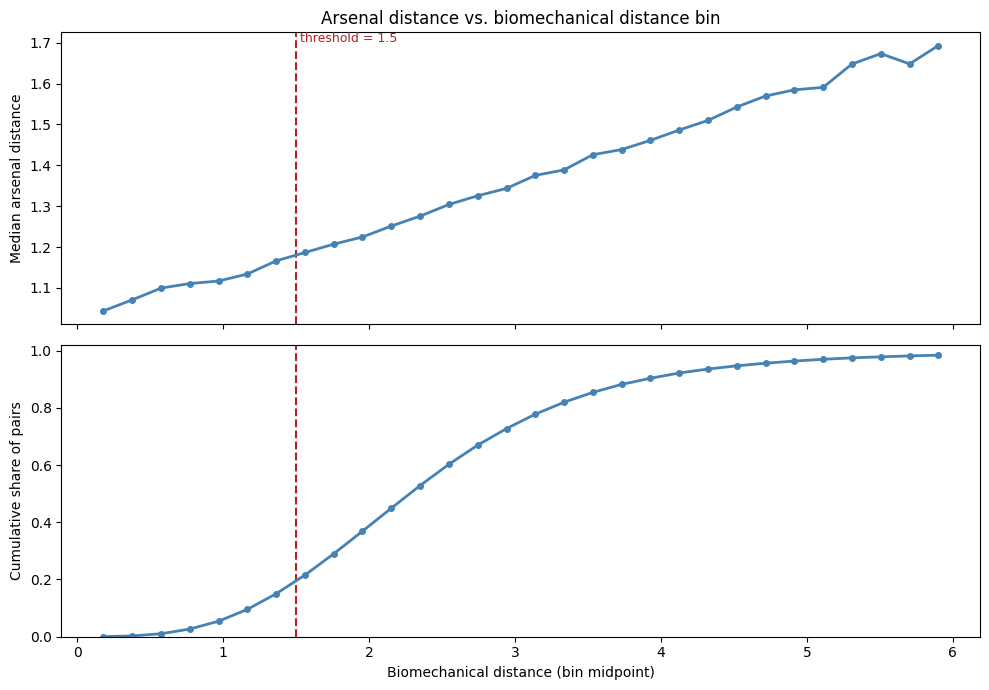

In [191]:
plot_threshold_calibration(biomech_thresh_r)

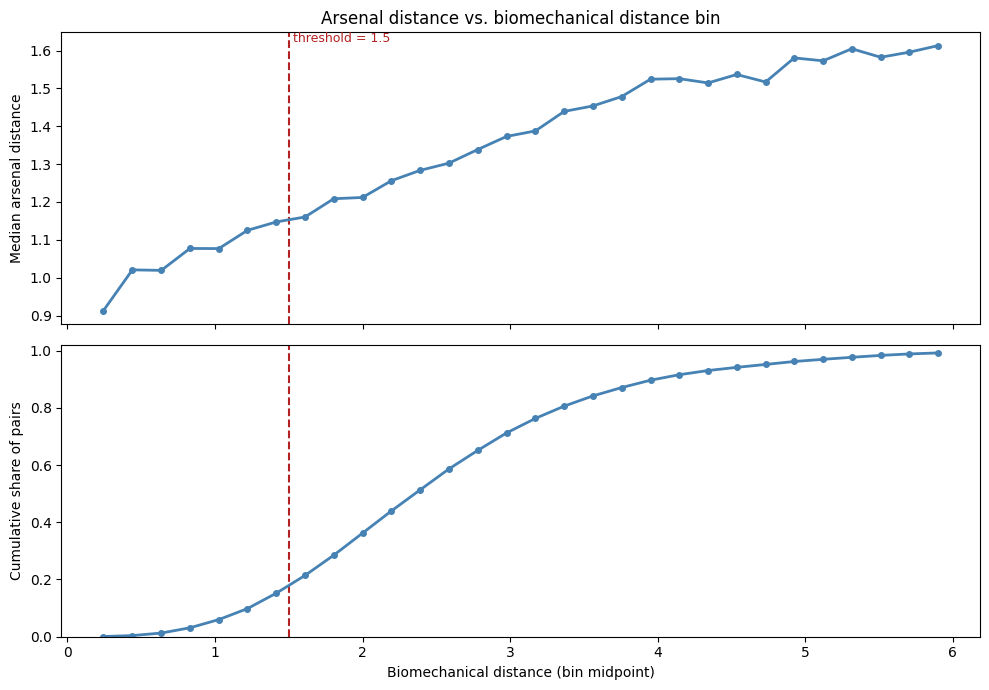

In [192]:
plot_threshold_calibration(biomech_thresh_l)

1.5 is the threshold due to solid balance of the two competing forces: the need for enough pitchers to offer sufficient comparisons, and the need for enough similarity for the comparisons to be relevant. The bottom graphs show 1.5 as well before the mass of the data and the biomech threshold coverage tables show 1.5 as having enough comparison pitchers in most cases. Additionally, examining at specific examples validates 1.5 as a good edge case.